# BITS F464 : Machine Learning - Assignment 5
Hand gesture recognition using Convolutional Neural Network

Adit Rastogi <br>
2022A7PS1330H <br><br>
Deeptansh Gupta <br>
2022A7PS1336H <br><br>
Anirban Nayak <br>
2022A3PS0705H <br>

## Data Loading and Preparation

### Importing the necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
import io

In [ ]:
data = pd.read_csv("./hand sign/sign_mnist_train.csv")
print(data.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206       204       20

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Loading the CSV file into pandas DataFrame

In [ ]:
df = pd.DataFrame(data)

### Mapping of ASL Hand Gestures with Alphabets

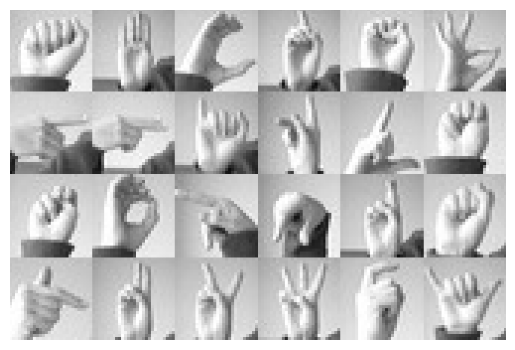

In [ ]:
from PIL import Image

image = Image.open('./hand sign/amer_sign3.png')

image.show()
plt.imshow(image)
plt.axis('off')
plt.show()


In [ ]:
labels_to_letters = {i: chr(97 + i) for i in range(26)}  # chr(97) is 'a'
print("Mapping of labels to letters:")
for label, letter in labels_to_letters.items():
    print(f"{label}: {letter}")

Mapping of labels to letters:
0: a
1: b
2: c
3: d
4: e
5: f
6: g
7: h
8: i
9: j
10: k
11: l
12: m
13: n
14: o
15: p
16: q
17: r
18: s
19: t
20: u
21: v
22: w
23: x
24: y
25: z


### Visualization of the letters

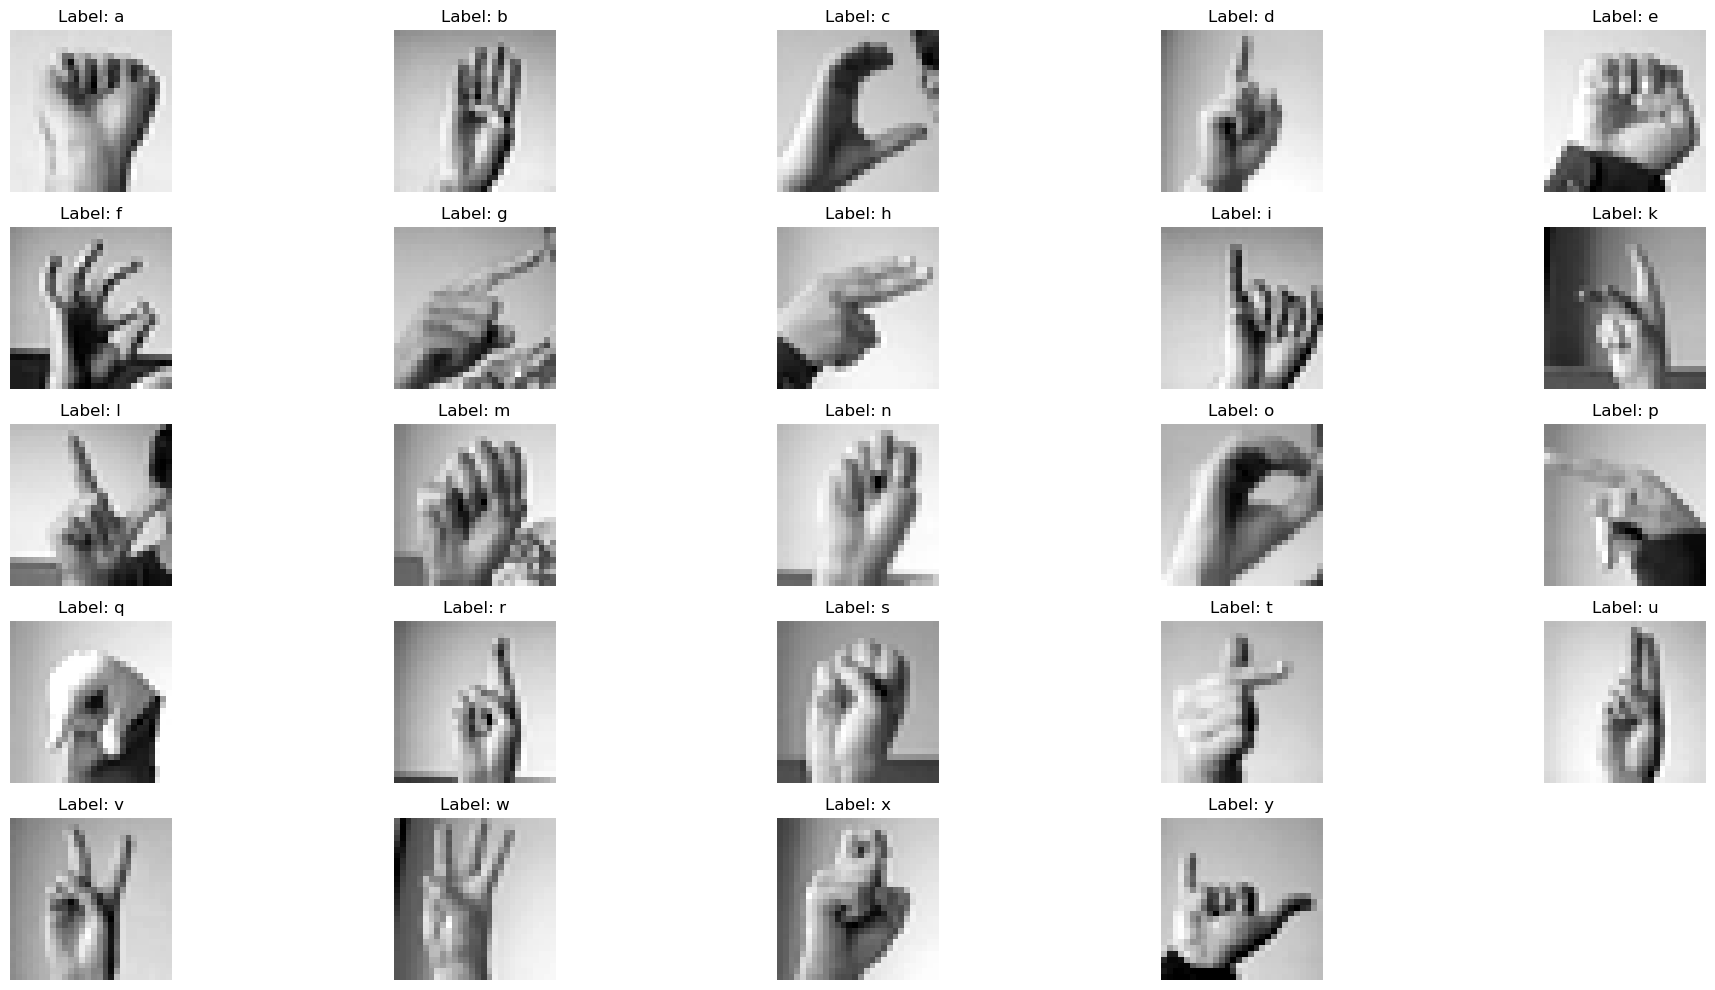

In [ ]:
import matplotlib.pyplot as plt

unique_data = data.groupby('label').first().reset_index()

# Visualize one image for each label
num_labels = len(unique_data)
plt.figure(figsize=(20, 10))

for i, row in unique_data.iterrows():
    # Reshape the pixel data into a 28x28 matrix
    image = row.iloc[1:].values.reshape(28, 28)  # Skip 'label' column
    label = int(row['label'])  # Ensure the label is an integer

    # Debugging: Print label and corresponding letter
    character = labels_to_letters[label]  # Get the corresponding letter

    plt.subplot(5, 5, i + 1)  # Adjust grid size if necessary
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {character}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Building the CNN Architecture

### The First Convolutional Layer

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))  # Input layer for 28x28 grayscale image
model.add(layers.Conv2D(
    filters=32,        # Number of filters
    kernel_size=(3, 3), # Kernel size (3x3)
    activation='relu',  # ReLU activation function
    padding='same'      # Padding to preserve spatial dimensions
))


### The Second Convolutional Layer

In [ ]:
model.add(layers.Conv2D(
    filters=64,        # Number of filters (increased from 32 to 64)
    kernel_size=(3, 3), # Kernel size (3x3)
    activation='relu',  # ReLU activation function
    padding='same'      # Padding to preserve spatial dimensions
))

### Max Pooling Layer

In [ ]:
# 3. Max Pooling Layer
model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # Pooling size of 2x2

# 4. Flatten the output of the convolutional layers to feed into the fully connected layer
model.add(layers.Flatten())

# 5. Fully Connected (Dense) Layer
model.add(layers.Dense(128, activation='relu'))  # Dense layer with 128 units and ReLU activation

# 6. Dropout Layer
model.add(layers.Dropout(0.28))  # Dropout with a rate of 28% to prevent overfitting

# 7. Output Layer
model.add(layers.Dense(26, activation='softmax'))  # 26 classes for alphabet (a-z)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary to check the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,627,930 (6.21 MB)

 Trainable params: 1,627,930 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

## Model Visualization

pydot version: 3.0.2


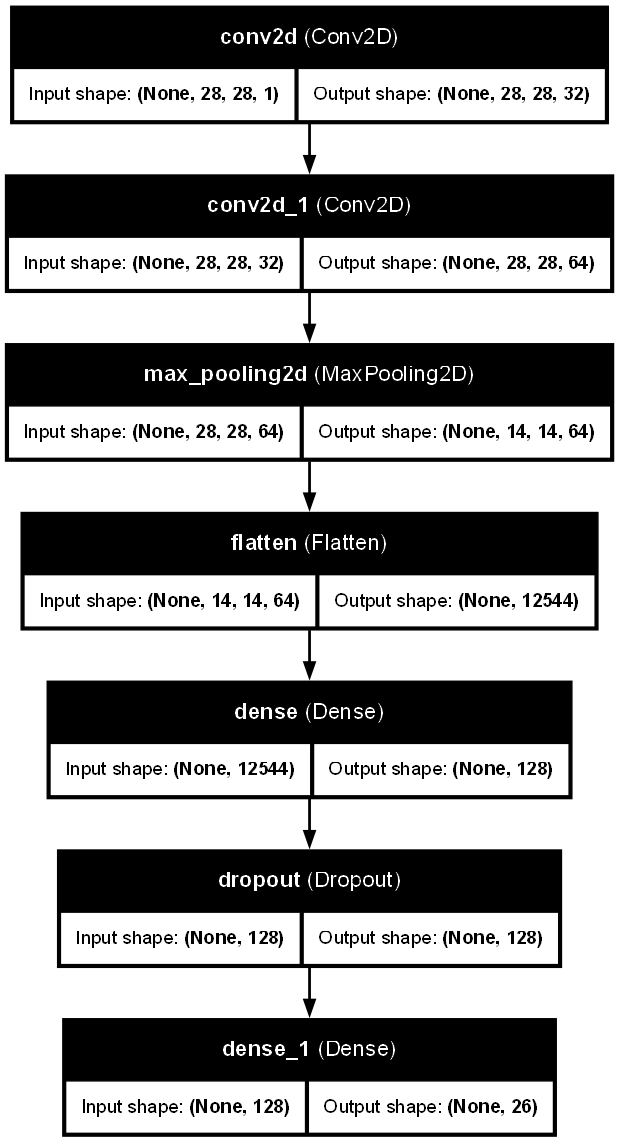

In [ ]:
import pydot
import graphviz
print("pydot version:", pydot.__version__)

plot_model(
    model,
    to_file='cnn_model.png',  # Save as an image file
    show_shapes=True,         # Display the shape of each layer's output
    show_layer_names=True,    # Display layer names
    expand_nested=True,       # Expand nested models, if any
    dpi=100                   # Resolution of the image
)

## Model Training

In [ ]:
from tensorflow.keras.optimizers import Adam, AdamW

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),  # or use AdamW(learning_rate=0.001)
    loss='categorical_crossentropy',     # For multi-class classification
    metrics=['accuracy']
)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Extract features and labels
labels = data['label'].values
features = data.drop('label', axis=1).values

# Normalize features (pixel values) to range [0, 1]
features = features / 255.0

# Reshape features to (N, 28, 28, 1)
features = features.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
labels = to_categorical(labels, num_classes=26)

# Split dataset into training and validation sets
# Split dataset into training, validation, and testing sets
train_features, temp_features, train_labels, temp_labels = train_test_split(
    features, labels, test_size=0.3, random_state=42
)
val_features, test_features, val_labels, test_labels = train_test_split(
    temp_features, temp_labels, test_size=0.5, random_state=42
)

print(f"Training set: {train_features.shape}, {train_labels.shape}")
print(f"Validation set: {val_features.shape}, {val_labels.shape}")
print(f"Testing set: {test_features.shape}, {test_labels.shape}")

Training set: (19218, 28, 28, 1), (19218, 26)
Validation set: (4118, 28, 28, 1), (4118, 26)
Testing set: (4119, 28, 28, 1), (4119, 26)


In [ ]:
history = model.fit(
    train_features,
    train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    batch_size=32,
    verbose=1
)

Epoch 1/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.3577 - loss: 2.1534 - val_accuracy: 0.9735 - val_loss: 0.1488
Epoch 2/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9103 - loss: 0.2767 - val_accuracy: 0.9995 - val_loss: 0.0166
Epoch 3/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9630 - loss: 0.1123 - val_accuracy: 0.9998 - val_loss: 0.0064
Epoch 4/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9737 - loss: 0.0764 - val_accuracy: 0.9998 - val_loss: 0.0027
Epoch 5/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9827 - loss: 0.0533 - val_accuracy: 0.9998 - val_loss: 0.0019
Epoch 6/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9831 - loss: 0.0520 - val_accuracy: 1.0000 - val_loss: 5.9692e-04
Epoch 7/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9850 - loss: 0.0437 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9883 - loss: 0.036

## Evaluation Plots

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_features, test_labels, verbose=1)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

## Results

In [3]:
data = {
    "Metric": ["Training Accuracy", "Validation Accuracy", "Training Loss", "Validation Loss"],
    "Start (Epoch 1)": ["35.77%", "97.35%", "2.1534", "0.1488"],
    "Convergence (Epoch 6)": ["98.31%", "100%", "0.0520", "0.00059692"],
    "Final (Epoch 20)": ["99.56%", "100%", "0.0138", "0.0000471"]
}

df = pd.DataFrame(data)
display(df)

,Metric,Start (Epoch 1),Convergence (Epoch 6),Final (Epoch 20)
0,Training Accuracy,35.77%,98.31%,99.56%
1,Validation Accuracy,97.35%,100%,100%
2,Training Loss,2.1534,0.0520,0.0138
3,Validation Loss,0.1488,0.00059692,0.0000471




1.   Training Accuracy: The training accuracy shows a sharp increase from 35.77% in Epoch 1 to 91.03% in Epoch 2 indicating rapid learning of basic patterns by the model. It continues to improve, reaching 99.56% by Epoch 16 and maintaining high performance afterward.

2.   Validation Accuracy: Validation accuracy is high from the beginning, achieving 97.35% in Epoch 1 and reaching 100% by Epoch 6 suggesting that the model generalizes well early in training and maintains this performance.

3. Training Loss: The loss starts at 2.1534, indicating substantial room for improvement in learning. It dramatically reduces to 0.2767, correlating with the jump in accuracy. The loss gradually decreases, reaching 0.0138 by Epoch 16, reflecting the model's ability to optimize for a nearly perfect training dataset.

4. Validation Loss: Validation loss drops significantly from 0.1488 to 0.0166, aligning with the rapid improvement in validation accuracy. It decreases to extremely low values, e.g., 0.0000471 by Epoch 17, suggesting excellent performance on unseen data.



## Second run with another Dropout Layer (Rate = 0.4)

In [ ]:
model = models.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))  # Input layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.Dropout(0.4))  # New dropout layer after convolutional layers
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.28))
model.add(layers.Dense(26, activation='softmax'))
model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
X = data.iloc[:, 1:].values  # Exclude the first column (label)
y = data['label'].values     # First column is the label

# Normalize the features (pixel values between 0 and 255)
X = X / 255.0

# Reshape the data to add a channel dimension (for grayscale images)
X = X.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y = to_categorical(y, num_classes=26)

# Split into training and validation sets
train_features, temp_features, train_labels, temp_labels = train_test_split(
    features, labels, test_size=0.3, random_state=42
)
val_features, test_features, val_labels, test_labels = train_test_split(
    temp_features, temp_labels, test_size=0.5, random_state=42
)

print(f"Training set: {train_features.shape}, {train_labels.shape}")
print(f"Validation set: {val_features.shape}, {val_labels.shape}")
print(f"Testing set: {test_features.shape}, {test_labels.shape}")

In [ ]:
history = model.fit(
    train_features,
    train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    batch_size=32,
    verbose=1
)

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_features, test_labels, verbose=1)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

## Observations



1.   Overfitting is not significant in this project, as evidenced by the close alignment of training and validation accuracy (both reaching 100% by Epoch 6). Validation loss consistently decreases, starting at 0.1488 in Epoch 1 and dropping to near-zero values like 0.0000471 in Epoch 20. The existing dropout layer at 28% likely contributes to this generalization.

2.   The CNN includes a Dropout(0.28) layer in the dense layers and a newly added Dropout(0.4) layer after the convolutional layers, which prevent overfitting by introducing regularization. Additionally, MaxPooling reduces spatial dimensions, and pixel normalization (scaling between 0 and 1) ensures stable and effective learning.

3. The addition of a Dropout(0.4) layer after convolution layers should further mitigate overfitting by randomizing feature learning in the convolutional stages. For example, the validation loss improvement from 0.00059692 in Epoch 6 to 0.0000471 in Epoch 20 suggests the existing dropout strategy works well, but further regularization could be beneficial for noisier datasets.

4. The CNN leverages shared structure property through 3 convolutional layers with 32, 64, and 64 filters, which extract local features like edges and textures across the entire image. The MaxPooling(2x2) layer ensures invariance by reducing feature sensitivity to spatial transformations, like shifts or rotations, while retaining essential patterns.

